## NYC SAT Performance Analysis

#### Objective
Analyze SAT performance across NYC public schools.

#### Dataset
schools.csv

In [2]:
import pandas as pd
schools = pd.read_csv("schools.csv")

In [3]:
schools.head()

,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.9
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.7


#### Which NYC schools have the best math results?

The best math results are at least 80% of the *maximum possible score of 800* for math.
Save your results in a pandas DataFrame called best_math_schools, including "school_name" and "average_math" columns, sorted by "average_math" in descending order

In [5]:
best_math_results= schools[schools['average_math']> 640] [['school_name','average_math']].sort_values(by='average_math', ascending=False)

In [6]:
print(best_math_results)

                                           school_name  average_math
88                              Stuyvesant High School           754
170                       Bronx High School of Science           714
93                 Staten Island Technical High School           711
365  Queens High School for the Sciences at York Co...           701
68   High School for Mathematics, Science, and Engi...           683
280                     Brooklyn Technical High School           682
333                        Townsend Harris High School           680
174  High School of American Studies at Lehman College           669
0    New Explorations into Science, Technology and ...           657
45                       Eleanor Roosevelt High School           641




### What are the top 10 performing schools based on the combined SAT scores?

Save your results as a pandas DataFrame called top_10_schools containing the "school_name" and a new column named "total_SAT", with results ordered by "total_SAT" in descending order ("total_SAT" being the sum of math, reading, and writing scores).

In [8]:
schools["total_SAT"] = schools["average_math"] + schools["average_reading"] + schools["average_writing"]

In [9]:
top_10_schools = schools[["school_name", "total_SAT"]] \
    .sort_values(by="total_SAT", ascending=False) \
    .head(10)

print(top_10_schools)

                                           school_name  total_SAT
88                              Stuyvesant High School       2144
170                       Bronx High School of Science       2041
93                 Staten Island Technical High School       2041
174  High School of American Studies at Lehman College       2013
333                        Townsend Harris High School       1981
365  Queens High School for the Sciences at York Co...       1947
5                       Bard High School Early College       1914
280                     Brooklyn Technical High School       1896
45                       Eleanor Roosevelt High School       1889
68   High School for Mathematics, Science, and Engi...       1889


Which single borough has the largest standard deviation in the combined SAT score?

Save your results as a pandas DataFrame called largest_std_dev.
The DataFrame should contain one row, with:
"borough" - the name of the NYC borough with the largest standard deviation of "total_SAT".
"num_schools" - the number of schools in the borough.
"average_SAT" - the mean of "total_SAT".
"std_SAT" - the standard deviation of "total_SAT".
Round all numeric values to two decimal places.

In [11]:
borough_stats =schools.groupby("borough").agg(
    num_schools=("school_name", "count"),
    avg_sat=("total_SAT", "mean"),
    std_sat=("total_SAT", "std")
)

In [12]:
print(borough_stats)

               num_schools      avg_sat     std_sat
borough                                            
Bronx                   98  1202.724490  150.393901
Brooklyn               109  1230.256881  154.868427
Manhattan               89  1340.134831  230.294140
Queens                  69  1345.478261  195.252899
Staten Island           10  1439.000000  222.303596


In [13]:
largest_std_dev = borough_stats.sort_values("std_sat", ascending=False).head(1).reset_index().round(2)

In [14]:
print("Top borough variability:", largest_std_dev["borough"][0])

Top borough variability: Manhattan


##### Insight
Manhattan shows the highest variability in SAT scores among schools.

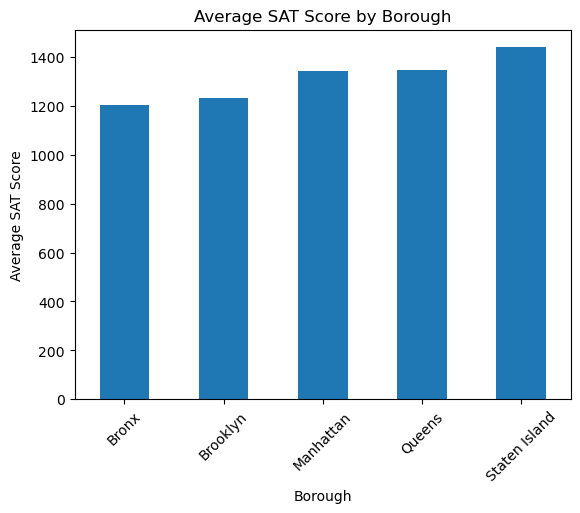

In [16]:
import matplotlib.pyplot as plt

borough_stats["avg_sat"].plot(kind="bar")

plt.title("Average SAT Score by Borough")
plt.xlabel("Borough")
plt.ylabel("Average SAT Score")
plt.xticks(rotation=45)

plt.show()